![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)


# Introducción a Transformers Architecture


* Profesor : [Carlos Daniel Jiménez Martínez](danieljimenez88m@gmail.com)

* Objetivo de la clase : Presentar como se trabaja computacionalemnte con modelos de lenguaje, de donde provienen y como se crean en si.

## Argumentos Base

* La ingeniería de AI consiste en 
    * Datos : Textos  no estrucutrados y multimodales
    * Procesos donde construir un contexto es lo importante , paso seguido hacer un prompt
    * Adaptación de los modelos (destilación) con fine tuning o eficiencia de los parámetros

* Los modelos core : codifican la información de manera que calcula matemáticamente que sencuiencia tiene mayor probabilidad de seguir en un texto:

    > Fue sin querer 

    > Fue sin querer **queriendo**

* AutoSupervision : Dado que los modelos requieren etiquetas para asi poder entrensarse, la estructura del lenguaje aprende prediciendo partes ocultas en los textyos crudos no etiquetados.

* La ingeniería de AI consiste en usar modelos fundacionales o vía API, donde :

    * Prompting -> Instrucciones
    * Rag -> El Contexto
    * Modelo -> Ajuste internos de los datos para entender como actuar de manera probabilistica

## Bases para que esto funcione de aquí en adelante
### Carácteristicas de un prompt 

Los prompts tanto para agentes como para Chatbots requieren de la siguiente ecuación , no la olvide, usela siempre :


* Role 
* Tarea
* Como debe ser el output
* Ejemplos (Nice to Have)
* Contexto

In [1]:
#######################
# ---- Librerias ---- #
#######################

import os
from openai import OpenAI
from dotenv import load_dotenv
import config  
from IPython.display import display, Markdown
client = OpenAI()

In [13]:
from enum import Enum

class OpenAIModels(str, Enum):  # str -> valores como cadenas | Enum -> enumeración
    GPT_5_5 = "gpt-5.5"
    GPT_5_MINI = "gpt-5-mini"

MODEL = OpenAIModels.GPT_5_MINI

In [14]:
def get_completion(system_prompt,           # Define el comportamiento del modelo
                   user_prompt,             # Solicitud del usuario
                   model=MODEL):

    messages = [{"role": "user", "content": user_prompt}]
    if system_prompt is not None:
        messages = [{"role": "system", "content": system_prompt}, *messages]
    try:
        response = client.chat.completions.create(
            model=model,
            messages=messages,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"An error occurred: {e}"

In [15]:
def display_responses(*args):
    """AYuda visual en formato markdown para comparar los modelos."""
    markdown_string = "<table><tr>"
    for arg in args:
        markdown_string += f"<th>System Prompt:<br />{arg['system_prompt']}<br /><br />"
        markdown_string += f"User Prompt:<br />{arg['user_prompt']}</th>"
    markdown_string += "</tr>"
    markdown_string += "<tr>"
    for arg in args:
        markdown_string += f"<td>Response:<br />{arg['response']}</td>"
    markdown_string += "</tr></table>"
    display(Markdown(markdown_string))

In [16]:
system_prompt = "Eres un conocedor en encrucijadas y en biologia animal, tu tarea es descifrar cuestiones de orden biologico como por ejemplo zoología y antropología-natural, quiero que la respuestas que des esten en formato json, a la hora de responder vete por una logica inductiva como que H2o resulta en Agua y HO2 Es Agua hidrogenizada. Para tus respuestas basate en el libro de Aleksandr Oparin y Richard Dawkins"
user_prompt = "Qué fue primero, el huevo o la gallina"

print('=='*32)
print(f'Enviar solicitud al modelo:  {MODEL}')
baseline_response = get_completion(system_prompt, user_prompt)
print('=='*32)
display_responses({
    "system_prompt": system_prompt,
    "user_prompt": user_prompt, 
    "response": baseline_response
})

Enviar solicitud al modelo:  OpenAIModels.GPT_5_MINI


<table><tr><th>System Prompt:<br />Eres un conocedor en encrucijadas y en biologia animal, tu tarea es descifrar cuestiones de orden biologico como por ejemplo zoología y antropología-natural, quiero que la respuestas que des esten en formato json, a la hora de responder vete por una logica inductiva como que H2o resulta en Agua y HO2 Es Agua hidrogenizada. Para tus respuestas basate en el libro de Aleksandr Oparin y Richard Dawkins<br /><br />User Prompt:<br />Qué fue primero, el huevo o la gallina</th></tr><tr><td>Response:<br />{
  "pregunta": "¿Qué fue primero, el huevo o la gallina?",
  "definiciones": {
    "huevo_generico": "Estructura reproductiva (célula o conjunto celular) que contiene un embrión en desarrollo; existe en muchos linajes anteriores a las aves.",
    "huevo_de_gallina": "Un huevo del que emerge un individuo cuya genómica califica como 'Gallus gallus domesticus' (primera criatura con el conjunto de alelos que definimos como gallina).",
    "gallina": "Individuo adulto perteneciente a la especie Gallus gallus domesticus, resultado de un proceso evolutivo acumulativo."
  },
  "razonamiento_inductivo": [
    {"nivel_1": "Moléculas simples (p. ej. nucleótidos, aminoácidos)"},
    {"nivel_2": "Sistemas auto-replicantes y protocélulas (Oparin: evolución química y surgimiento de compartimentos)"},
    {"nivel_3": "Células y multicelularidad con reproducción sexual y asexual"},
    {"nivel_4": "Vertebrados y amniotas que desarrollan huevos con envolturas protectoras"},
    {"nivel_5": "Dinosaurios/aves primitivas que ya ponían huevos (huevos preceden específicamente a las aves modernas)"},
    {"nivel_6": "Poblaciones de aves cercanas al ancestro del pollo moderno (proto-gallinas) con variación genética"},
    {"nivel_7": "Mutación(s) acumuladas en la línea germinal dan lugar al primer individuo que podemos llamar 'gallina'—ese individuo surgió de un huevo"}
  ],
  "argumentos_teóricos": {
    "segun_Oparin": "Oparin propone que la vida y los mecanismos reproductivos emergen por evolución química y selección; la aparición de compartimentos y replicadores permite formas de reproducción antes de especies modernas, sugiriendo que estructuras protectoras tipo huevo son anteriores a especies concretas.",
    "segun_Dawkins": "Dawkins, desde la perspectiva del gen como unidad de selección, explica que los cambios favorables se acumulan gradualmente. Una 'nueva especie' aparece cuando la combinación de alelos alcanza el umbral que la define; ese cambio sucede en el material hereditario, típicamente transmitido vía huevo/óvulo o cigoto."
  },
  "análisis_mutacional": "Un par de aves 'proto-gallinas' produjo gametos con pequeñas diferencias. La recombinación y/o mutación en el cigoto que se desarrolló dentro de un huevo produjo el primer individuo con el conjunto de alelos que definimos como gallina. Por tanto, el 'primer individuo gallina' emergió de un huevo puesto por padres que no eran exactamente gallinas.",
  "conclusión": {
    "respuesta_breve": "El huevo (en sentido evolutivo) fue antes que la gallina.",
    "matización": "Si por 'huevo' se entiende cualquier huevo de vertebrado u ovoide reproductivo, los huevos existían mucho antes que las gallinas. Si por 'huevo de gallina' se entiende 'huevo puesto por una gallina', entonces la primera gallina debió existir antes del primer huevo puesto por una gallina; pero el primer individuo que cumplió la definición de gallina nació de un huevo puesto por una proto-gallina."
  },
  "nota": "Esta respuesta combina la visión de Oparin sobre el origen químico y el surgimiento de mecanismos reproductivos con la visión de Dawkins sobre selección y acumulación de mutaciones en genes.",
  "referencias": [
    "A. I. Oparin, 'The Origin of Life' (ideas sobre evolución química y formación de sistemas replicantes)",
    "R. Dawkins, 'The Selfish Gene' (visión del gen como unidad de selección y explicación de la aparición gradual de rasgos)"
  ]
}</td></tr></table>

### Transfomers 

* Proceso de tranformación de tokens en paralelo para generar entrenamiento de modelos 

* Esto se basa en modelos atencionales que consuisten en ver la importancia matemática de todos los tokens para generar el siguiente 

* Esto se logra gracias a Multi-head Attention: sistema masivo de recuperación de información

![](https://upload.wikimedia.org/wikipedia/commons/thumb/3/34/Transformer%2C_full_architecture.png/960px-Transformer%2C_full_architecture.png)



In [17]:
import pandas as pd
import numpy as np
import tiktoken

In [18]:
text = """"Nosotros no somos como los Orozco,
Yo los conozco, son ocho los monos:
Pocho, Toto, Cholo, Tom,
Moncho, Rodolfo, Otto, Pololo.
Yo pongo los votos sólo por Rodolfo,
Los otros son locos, yo los conozco, no los soporto.
Stop. Stop."""


encoding = tiktoken.get_encoding("o200k_base")  

token_ids = encoding.encode(text)
print(f"IDs de Tokens: {token_ids}")

tokens_text = [encoding.decode_single_token_bytes(t).decode("utf-8") for t in token_ids]
print(f"Tokens de texto: {tokens_text}")

df_tokens = pd.DataFrame({"Token ID": token_ids, "Token Text": tokens_text})
print(df_tokens)

IDs de Tokens: [1, 40136, 25265, 860, 42665, 2526, 1403, 532, 39381, 1191, 412, 50385, 1403, 116835, 1191, 11, 2391, 87850, 1403, 189602, 734, 25010, 2153, 11, 143976, 11, 1036, 5539, 11, 11838, 412, 7088, 2153, 11, 19179, 142467, 11, 99541, 11, 4312, 5539, 558, 50385, 185486, 1403, 66160, 23686, 1382, 19179, 142467, 412, 16593, 15998, 2391, 1539, 365, 11, 7243, 1403, 116835, 1191, 11, 860, 1403, 813, 60901, 558, 13523, 13, 22535, 13]
Tokens de texto: ['"', 'Nos', 'otros', ' no', ' somos', ' como', ' los', ' O', 'roz', 'co', ',\n', 'Yo', ' los', ' conoz', 'co', ',', ' son', ' ocho', ' los', ' monos', ':\n', 'Po', 'cho', ',', ' Toto', ',', ' Ch', 'olo', ',', ' Tom', ',\n', 'Mon', 'cho', ',', ' Rod', 'olfo', ',', ' Otto', ',', ' Pol', 'olo', '.\n', 'Yo', ' pongo', ' los', ' votos', ' sólo', ' por', ' Rod', 'olfo', ',\n', 'Los', ' otros', ' son', ' loc', 'os', ',', ' yo', ' los', ' conoz', 'co', ',', ' no', ' los', ' so', 'porto', '.\n', 'Stop', '.', ' Stop', '.']
    Token ID Token Text


In [19]:
response = client.embeddings.create(
    input=text,
    model="text-embedding-3-small"
)

embedding_vector = response.data[0].embedding
print(f"Dimensión del vector: {len(embedding_vector)}") 
print(f"Primeros 15 valores: {embedding_vector[:15]}")

Dimensión del vector: 1536
Primeros 15 valores: [0.0330810546875, -0.0130157470703125, -0.0855712890625, -0.03021240234375, -0.020050048828125, -0.0113067626953125, -0.01033782958984375, 0.042877197265625, -0.05230712890625, -0.0679931640625, -0.03533935546875, -0.021636962890625, 0.0003764629364013672, 0.007720947265625, 0.0223846435546875]


In [21]:
prompt = """Completa la siguiente frase:  Nosotros no somos como los Orozco,
Yo los conozco, son ocho los monos:
Pocho, Toto, Cholo, Tom,
Moncho, Rodolfo, Otto, Pololo.
Yo pongo los votos sólo por Rodolfo,
Los otros son locos"""


response = client.chat.completions.create(
    model="gpt-4o",
    messages=[{"role": "user", "content": prompt}],
    max_tokens=15,
    logprobs=True,      
    top_logprobs=5,     
)

generated_content = response.choices[0].message.content
print(f"Prompt: {prompt}")
print(f"Completado: {generated_content}\n")

for i, tok in enumerate(response.choices[0].logprobs.content):
    print(f"Token {i}: {tok.token!r}  logprob={tok.logprob:.4f}")
    for alt in tok.top_logprobs:
        print(f"    alt: {alt.token!r}  logprob={alt.logprob:.4f}")

Prompt: Completa la siguiente frase:  Nosotros no somos como los Orozco,
Yo los conozco, son ocho los monos:
Pocho, Toto, Cholo, Tom,
Moncho, Rodolfo, Otto, Pololo.
Yo pongo los votos sólo por Rodolfo,
Los otros son locos
Completado: y yo no los soporto.

Token 0: 'y'  logprob=-0.1603
    alt: 'y'  logprob=-0.1603
    alt: 'Lo'  logprob=-2.5040
    alt: ','  logprob=-4.0665
    alt: 'Aquí'  logprob=-4.1603
    alt: 'e'  logprob=-5.2853
Token 1: ' yo'  logprob=-2.1234
    alt: ' poco'  logprob=-0.2953
    alt: ' yo'  logprob=-2.1234
    alt: ' pocos'  logprob=-3.5766
    alt: ' casi'  logprob=-3.6859
    alt: ' de'  logprob=-3.8578
Token 2: ' no'  logprob=-0.1693
    alt: ' no'  logprob=-0.1693
    alt: ' me'  logprob=-2.6225
    alt: ' ni'  logprob=-2.8725
    alt: ' los'  logprob=-3.7631
    alt: ' ya'  logprob=-6.3100
Token 3: ' los'  logprob=-0.4316
    alt: ' los'  logprob=-0.4316
    alt: ' me'  logprob=-1.1034
    alt: ' hago'  logprob=-5.8534
    alt: ' estoy'  logprob=-5.9941
 

In [22]:
print("--- Inspección de Probabilidades (Looking Inside) ---")
for i, token_data in enumerate(response.choices[0].logprobs.content):
    token = token_data.token
    prob = np.exp(token_data.logprob) * 100  # Convertir logprob a % real
    
    print(f"\nPaso {i+1}: Token elegido -> '{token}' ({prob:.2f}% confianza)")
    
    print("   Otras opciones consideradas:")
    for top_k in token_data.top_logprobs:
        top_prob = np.exp(top_k.logprob) * 100
        print(f"     - '{top_k.token}': {top_prob:.2f}%")

--- Inspección de Probabilidades (Looking Inside) ---

Paso 1: Token elegido -> 'y' (85.19% confianza)
   Otras opciones consideradas:
     - 'y': 85.19%
     - 'Lo': 8.18%
     - ',': 1.71%
     - 'Aquí': 1.56%
     - 'e': 0.51%

Paso 2: Token elegido -> ' yo' (11.96% confianza)
   Otras opciones consideradas:
     - ' poco': 74.43%
     - ' yo': 11.96%
     - ' pocos': 2.80%
     - ' casi': 2.51%
     - ' de': 2.11%

Paso 3: Token elegido -> ' no' (84.42% confianza)
   Otras opciones consideradas:
     - ' no': 84.42%
     - ' me': 7.26%
     - ' ni': 5.66%
     - ' los': 2.32%
     - ' ya': 0.18%

Paso 4: Token elegido -> ' los' (64.95% confianza)
   Otras opciones consideradas:
     - ' los': 64.95%
     - ' me': 33.17%
     - ' hago': 0.29%
     - ' estoy': 0.25%
     - ' respon': 0.21%

Paso 5: Token elegido -> ' so' (99.09% confianza)
   Otras opciones consideradas:
     - ' so': 99.09%
     - ' col': 0.23%
     - ' apoyo': 0.15%
     - ' soport': 0.10%
     - ' compro': 0.05%



### Embeddings

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from dotenv import find_dotenv, load_dotenv
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import chromadb
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
import time
import warnings

/Users/carlosdaniel/Desktop/HENRY_EMBEDDINGS_RAGS/Clase2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


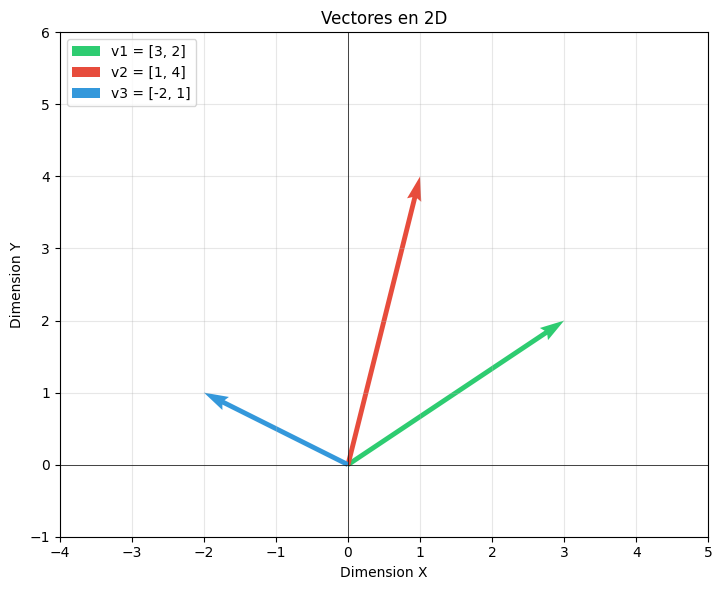

In [25]:
# Definir vectores 2D
v1 = np.array([3, 2])
v2 = np.array([1, 4])
v3 = np.array([-2, 1])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

origin = np.array([0, 0])
vectors = [v1, v2, v3]
colors = ['#2ecc71', '#e74c3c', '#3498db']
labels = ['v1 = [3, 2]', 'v2 = [1, 4]', 'v3 = [-2, 1]']

for v, c, l in zip(vectors, colors, labels):
    ax.quiver(*origin, *v, angles='xy', scale_units='xy', scale=1,
              color=c, linewidth=2.5, label=l)

ax.set_xlim(-4, 5)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('Dimension X')
ax.set_ylabel('Dimension Y')
ax.set_title('Vectores en 2D')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [26]:
# Magnitud de un vector: |v| = sqrt(x^2 + y^2)
for v, l in zip(vectors, labels):
    mag = np.linalg.norm(v)
    print(f"{l}  ->  magnitud = {mag:.4f}")

print("\nLa magnitud indica 'cuanto' hay de algo, la direccion indica 'que tipo'.")

v1 = [3, 2]  ->  magnitud = 3.6056
v2 = [1, 4]  ->  magnitud = 4.1231
v3 = [-2, 1]  ->  magnitud = 2.2361

La magnitud indica 'cuanto' hay de algo, la direccion indica 'que tipo'.


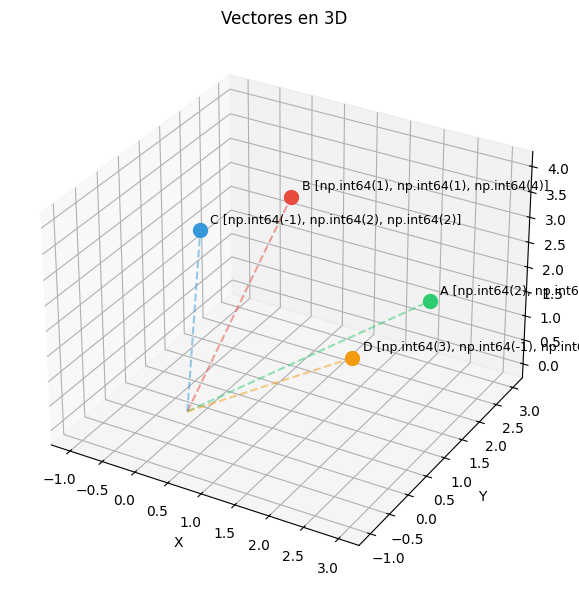

In [27]:
# Vectores 3D
points_3d = np.array([
    [2, 3, 1],
    [1, 1, 4],
    [-1, 2, 2],
    [3, -1, 3],
])
labels_3d = ['A', 'B', 'C', 'D']
colors_3d = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for p, c, l in zip(points_3d, colors_3d, labels_3d):
    ax.scatter(*p, color=c, s=100, depthshade=True)
    ax.text(p[0]+0.1, p[1]+0.1, p[2]+0.1, f"{l} {list(p)}", fontsize=9)
    ax.plot([0, p[0]], [0, p[1]], [0, p[2]], color=c, alpha=0.5, linestyle='--')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Vectores en 3D')

plt.tight_layout()
plt.show()

In [45]:
textos = [
    "Mina",
    "Chica",
    "Mujer",
]

response = client.embeddings.create(
    input=textos,
    model="text-embedding-3-small"
)

embeddings_openai = np.array([e.embedding for e in response.data])

print(f"Forma del array: {embeddings_openai.shape}")
print(f"Dimensiones por embedding: {embeddings_openai.shape[1]}")
print(f"\nPrimeros 10 valores del primer embedding:")
print(embeddings_openai[0][:10])

Forma del array: (3, 1536)
Dimensiones por embedding: 1536

Primeros 10 valores del primer embedding:
[ 0.01409149  0.0094986   0.00589371 -0.00417709 -0.05020142 -0.00756454
  0.03213501  0.01537323 -0.0050621  -0.04141235]


In [50]:
### Creando mi primer función 

def calculo_del_coseno(a,b):
    dot = np.dot(a,b)
    norma_a = np.linalg.norm(a)
    norma_b= np.linalg.norm(b)
    return dot/(norma_a * norma_b)

for i in range(len(textos)):
    for j in range(i + 1 , len(textos )):
        sim = calculo_del_coseno(embeddings_openai[i], embeddings_openai[j])
        print('=='*32)
        print(f" '{textos[i]}'")
        print(f" '{textos[j]}'")
        print(f"La similaridad entre esta dupla es :{sim:.2f} %")
        print('=='*32)

    

 'Coche'
 'Carro'
La similaridad entre esta dupla es :0.39 %
 'Coche'
 'Automovil'
La similaridad entre esta dupla es :0.34 %
 'Carro'
 'Automovil'
La similaridad entre esta dupla es :0.55 %


In [52]:
textos = [
    "Coche",
    "Carro",
    "Automovil",
]
print(np.round(calculo_del_coseno(embeddings_openai,4)))

[[ 0.  0.  0. ... -0.  0.  0.]
 [ 0. -0. -0. ... -0.  0.  0.]
 [ 0. -0. -0. ... -0. -0.  0.]]
